# 09 - Uso do Modelo no Negócio

O modelo não decide pelo hotel. O papel dele é ajudar a equipe de reservas
a decidir. Neste notebook vejo, com os dados do teste, se
o modelo é útil para isso.

Primeiro comparo o modelo com o que o hotel conseguiria sem ele. Depois
mostro os três usos que defini no notebook 01:

1. saber em quais reservas vale a pena ficar de olho;
2. prever quantos cancelamentos vão acontecer em cada período;
3. dar atenção primeiro às reservas que mais pesam na receita.

No final vejo até quanto pode custar um alarme falso para o modelo ainda
valer a pena, e mostro como o modelo dá uma nota para uma reserva.

Uso o modelo salvo no notebook 07, como um sistema do hotel faria. Por isso o
notebook 07 precisa ser executado antes.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import json
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import average_precision_score

from src.preprocessing import preparar, separar_treino_teste, ALVO

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
pasta = Path("../models")
modelo = joblib.load(pasta / "final_pipeline.joblib")
config = json.loads((pasta / "final_config.json").read_text(encoding="utf-8"))
LIMIAR = config["limiar"]
variaveis = config["variaveis"]
print("modelo:", config["modelo"], "| limiar:", LIMIAR, "| treinado em:", config["treinado_em"])

df = preparar(historico=True)
treino, teste = separar_treino_teste(df)
teste = teste.copy()
teste["prob"] = modelo.predict_proba(teste[variaveis])[:, 1]
teste["alerta"] = (teste["prob"] >= LIMIAR).astype(int)
y = teste[ALVO].values
print("reservas no teste:", len(teste), "| cancelamentos:", int(y.sum()))

modelo: XGBoost | limiar: 0.4 | treinado em: 2026-09-27


reservas no teste: 23842 | cancelamentos: 9741


## 2. O modelo contra não usar modelo

Comparo, no mesmo período de teste:

- não marcar nenhuma reserva (é o que acontece quando todas são tratadas
  igual);
- marcar todas as reservas;
- a regra simples do notebook 04;
- o modelo com limiar de 0,4;
- o modelo com o mesmo número de alertas da regra, pegando as reservas de
  maior risco. Assim a comparação com a regra fica justa.

In [3]:
def regra_simples(d):
    return ((d["deposit_type"] == "Non Refund")
            | (d["previous_cancellations"] > 0)
            | (d["lead_time"] > 180)).astype(int).values

def resumo(pred, y_ref):
    acertos = int(((pred == 1) & (y_ref == 1)).sum())
    falsos = int(((pred == 1) & (y_ref == 0)).sum())
    return {"alertas": int(pred.sum()), "acertos": acertos, "alarmes_falsos": falsos,
            "precision": acertos / max(int(pred.sum()), 1), "recall": acertos / int(y_ref.sum())}

def top_k(prob, k):
    pred = np.zeros(len(prob), dtype=int)
    pred[np.argsort(-prob)[:k]] = 1
    return pred

inteiros = {"alertas": int, "acertos": int, "alarmes_falsos": int}
regra = regra_simples(teste)
k = int(regra.sum())

pd.DataFrame({
    "sem modelo": resumo(np.zeros(len(teste), dtype=int), y),
    "alertar todas": resumo(np.ones(len(teste), dtype=int), y),
    "regra simples": resumo(regra, y),
    "modelo (limiar 0,4)": resumo(teste["alerta"].values, y),
    f"modelo ({k} alertas, como a regra)": resumo(top_k(teste["prob"].values, k), y),
}).T.astype(inteiros)

,alertas,acertos,alarmes_falsos,precision,recall
sem modelo,0,0,0,0.000,0.000
alertar todas,23842,9741,14101,0.409,1.000
regra simples,8340,4737,3603,0.568,0.486
"modelo (limiar 0,4)",10493,7850,2643,0.748,0.806
"modelo (8340 alertas, como a regra)",8340,6735,1605,0.808,0.691


- sem modelo, o hotel não vê nenhum cancelamento. Marcando todas, vê todos,
  mas 59% dos alertas são falsos e o trabalho fica inviável;
- a regra simples pega menos da metade dos cancelamentos (recall 0,486) e só
  57 de cada 100 alertas estão certos;
- com o mesmo número de alertas da regra (8.340), o modelo pega 6.735
  cancelamentos contra 4.737 da regra, com menos da metade dos alarmes falsos
  (1.605 contra 3.603).

Com o mesmo esforço da equipe, o modelo encontra 42% mais cancelamentos que
a regra.

## 3. Reservas sem depósito

Nas reservas não reembolsáveis o valor não é devolvido. Se elas cancelam, o
hotel perde a ocupação mas fica com o dinheiro. E como quase sempre
cancelam, qualquer regra acerta. O cancelamento que realmente faz o hotel
perder receita é o das reservas sem depósito. Por isso repito a comparação só
com elas:

In [4]:
sem_dep = teste[teste["deposit_type"] == "No Deposit"].copy()
y_sd = sem_dep[ALVO].values
regra_sd = regra_simples(sem_dep)
k_sd = int(regra_sd.sum())

print("reservas sem depósito:", len(sem_dep), f"| taxa de cancelamento: {y_sd.mean():.3f}",
      f"| PR-AUC do modelo: {average_precision_score(y_sd, sem_dep['prob']):.3f}")

pd.DataFrame({
    "regra simples": resumo(regra_sd, y_sd),
    "modelo (limiar 0,4)": resumo(sem_dep["alerta"].values, y_sd),
    f"modelo ({k_sd} alertas, como a regra)": resumo(top_k(sem_dep["prob"].values, k_sd), y_sd),
}).T.astype(inteiros)

reservas sem depósito: 21528 | taxa de cancelamento: 0.345 | PR-AUC do modelo: 0.756


,alertas,acertos,alarmes_falsos,precision,recall
regra simples,6041,2439,3602,0.404,0.328
"modelo (limiar 0,4)",8185,5542,2643,0.677,0.746
"modelo (6041 alertas, como a regra)",6041,4435,1606,0.734,0.597


Aqui a diferença é bem maior. Sem a ajuda do depósito não reembolsável, a
regra quase não funciona: só 40% dos alertas estão certos e ela pega um
terço dos cancelamentos. Com o mesmo número de alertas, o modelo pega 4.435
cancelamentos contra 2.439 da regra, quase o dobro. É nessas reservas, que
são as que custam receita, que o modelo mais ajuda.

## 4. Uso 1: saber em quais reservas ficar de olho

Transformo a probabilidade em três faixas de risco, que são mais fáceis para
a equipe usar. A faixa média começa no limiar de 0,4 e a alta em 0,7. Escolhi
0,7 porque no conjunto de ajuste do notebook 06, a partir desse valor, 90%
dos avisos eram cancelamentos. Para cada faixa comparo a probabilidade média prevista com a taxa real de
cancelamento no teste.

In [5]:
faixas = pd.cut(teste["prob"], [0, LIMIAR, 0.7, 1.0001], right=False,
                labels=["baixo", "médio", "alto"]).rename("faixa")

tab_faixas = teste.groupby(faixas, observed=True).agg(reservas=(ALVO, "size"),
                                                       prob_media=("prob", "mean"),
                                                       taxa_real=(ALVO, "mean"))
tab_faixas["% das reservas"] = tab_faixas["reservas"] / len(teste) * 100
tab_faixas["% dos cancelamentos"] = teste.groupby(faixas, observed=True)[ALVO].sum() / y.sum() * 100
tab_faixas

,reservas,prob_media,taxa_real,% das reservas,% dos cancelamentos
faixa,,,,,
baixo,13349,0.121,0.142,55.989,19.413
médio,4541,0.562,0.583,19.046,27.174
alto,5952,0.880,0.874,24.964,53.413


As faixas separam bem o risco, e a probabilidade média fica perto da taxa
real em cada uma (na faixa alta o modelo prevê 0,880 e 87% cancelam). A
faixa alta tem 25% das reservas e 53% dos cancelamentos.

Um jeito de a equipe usar as faixas:

- alto (0,7 ou mais): confirmar a reserva com o cliente perto da data e já
  contar com a chance de o quarto ficar livre ao planejar a ocupação e o
  overbooking;
- médio (de 0,4 a 0,7): acompanhar, por exemplo com um lembrete antes da
  chegada;
- baixo (menos de 0,4): nada de especial.

Essas ações são sugestões. O modelo mostra quais reservas merecem atenção,
mas não mede se uma ação funciona (por exemplo, se uma ligação evita o
cancelamento), porque a base não registra o que o hotel fez com cada
reserva. Para medir isso seria preciso testar as ações e guardar os
resultados.

## 5. Uso 2: prever quantos cancelamentos vão acontecer

Como a probabilidade do modelo é confiável (notebook 06), somando as
probabilidades das reservas de um período tenho uma previsão de quantas vão
cancelar. Isso ajuda a prever a ocupação real e a decidir quanto overbooking
aceitar.

Comparo semana a semana no teste: os cancelamentos reais, a previsão do
modelo e uma previsão simples que usa a taxa histórica do treino (0,361) para
todas as reservas.

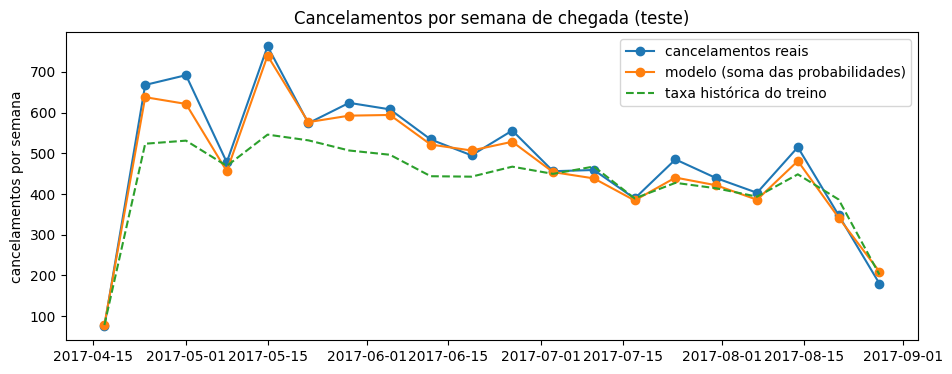

total no teste: previsto pelo modelo 9411 | real 9741
erro médio por semana: modelo 4.6% | taxa histórica 11.3%


In [6]:
taxa_historica = treino[ALVO].mean()

teste["semana"] = teste["arrival_date"].dt.to_period("W").dt.start_time
por_semana = teste.groupby("semana").agg(reservas=(ALVO, "size"), real=(ALVO, "sum"),
                                         previsto=("prob", "sum"))
por_semana["taxa histórica"] = por_semana["reservas"] * taxa_historica

plt.figure(figsize=(11, 4))
plt.plot(por_semana.index, por_semana["real"], marker="o", label="cancelamentos reais")
plt.plot(por_semana.index, por_semana["previsto"], marker="o", label="modelo (soma das probabilidades)")
plt.plot(por_semana.index, por_semana["taxa histórica"], linestyle="--", label="taxa histórica do treino")
plt.ylabel("cancelamentos por semana")
plt.title("Cancelamentos por semana de chegada (teste)")
plt.legend()
plt.show()

erro_modelo = ((por_semana["previsto"] / por_semana["real"] - 1).abs() * 100).mean()
erro_historico = ((por_semana["taxa histórica"] / por_semana["real"] - 1).abs() * 100).mean()
print(f"total no teste: previsto pelo modelo {por_semana['previsto'].sum():.0f} | real {por_semana['real'].sum():.0f}")
print(f"erro médio por semana: modelo {erro_modelo:.1f}% | taxa histórica {erro_historico:.1f}%")

In [7]:
teste["mes"] = teste["arrival_date"].dt.to_period("M").astype(str)
por_mes = teste.groupby("mes").agg(reservas=(ALVO, "size"), real=(ALVO, "sum"), previsto=("prob", "sum"))
por_mes["taxa histórica"] = por_mes["reservas"] * taxa_historica
por_mes["erro do modelo (%)"] = (por_mes["previsto"] / por_mes["real"] - 1) * 100
por_mes["erro da taxa histórica (%)"] = (por_mes["taxa histórica"] / por_mes["real"] - 1) * 100
por_mes.round(1)

,reservas,real,previsto,taxa histórica,erro do modelo (%),erro da taxa histórica (%)
mes,,,,,,
2017-04,1665,743,716.300,601.600,-3.600,-19.000
2017-05,6305,2762,2644.700,2278.100,-4.200,-17.500
2017-06,5639,2438,2368.900,2037.500,-2.800,-16.400
2017-07,5310,1984,1910.600,1918.600,-3.700,-3.300
2017-08,4923,1814,1770.000,1778.800,-2.400,-1.900


No teste inteiro o modelo previu 9.411 cancelamentos e aconteceram 9.741. Por
semana, o erro médio do modelo é de 4,6%, contra 11,3% da taxa histórica. A
semana com mais erro é a última, que está incompleta e tem poucas reservas.

Por mês a diferença fica mais clara. O modelo fica sempre um pouco abaixo do
real, entre 2% e 4%, porque no período de teste se cancela mais que no
treino. A taxa histórica erra bem mais: subestima os cancelamentos de abril a
junho entre 16% e 19%. O modelo acompanha quase toda essa mudança porque olha
o perfil de cada reserva, enquanto a taxa histórica é uma média do passado.

Para o hotel, isso quer dizer planejar a ocupação com uma estimativa bem
mais próxima da realidade.

## 6. Uso 3: dar atenção primeiro ao que pesa na receita

Duas reservas com o mesmo risco podem valer muito diferente: sete noites
caras pesam mais que uma noite barata. Então junto o risco com o valor da
reserva:

`valor em risco = probabilidade × adr × total_nights`

Olho só as reservas sem depósito, que são as que fazem o hotel perder
receita. A pergunta é: se a equipe só consegue acompanhar uma parte das
reservas, quanto da receita perdida com cancelamentos ela cobre, dependendo
de como escolhe essas reservas?

In [8]:
sem_dep["valor"] = sem_dep["adr"] * sem_dep["total_nights"]
sem_dep["valor_em_risco"] = sem_dep["prob"] * sem_dep["valor"]
receita_perdida = sem_dep.loc[sem_dep[ALVO] == 1, "valor"].sum()
print(f"receita das reservas sem depósito que cancelaram: {receita_perdida:,.0f}")

linhas = []
for frac in [0.10, 0.20, 0.30]:
    n = int(len(sem_dep) * frac)
    por_valor = sem_dep.nlargest(n, "valor_em_risco")
    por_risco = sem_dep.nlargest(n, "prob")
    linhas.append({"reservas acompanhadas": f"{frac:.0%} ({n})",
                   "ordenando por valor em risco (%)": por_valor.loc[por_valor[ALVO] == 1, "valor"].sum() / receita_perdida * 100,
                   "ordenando só pelo risco (%)": por_risco.loc[por_risco[ALVO] == 1, "valor"].sum() / receita_perdida * 100,
                   "ao acaso (%)": frac * 100})
pd.DataFrame(linhas).set_index("reservas acompanhadas").round(1)

receita das reservas sem depósito que cancelaram: 4,466,333


,ordenando por valor em risco (%),ordenando só pelo risco (%),ao acaso (%)
reservas acompanhadas,,,
10% (2152),45.300,28.800,10.000
20% (4305),65.700,49.100,20.000
30% (6458),78.900,66.800,30.000


Acompanhando só 10% das reservas sem depósito, escolhidas pelo valor em
risco, a equipe cobre 45% da receita perdida com cancelamentos. Escolhendo só
pelo risco cobriria 29%, e ao acaso, 10%. Com 30% das reservas, o valor em
risco cobre 79%.

Então juntar a probabilidade com o valor da reserva ajuda a equipe a gastar o
esforço onde tem mais dinheiro em jogo. O valor está na unidade do `adr` da
base, que não informa a moeda, por isso olho só as porcentagens.

## 7. Até quanto um alarme falso pode custar?

A base não tem o custo real de um cancelamento nem de um alarme falso. Mas
dá para ver até quanto um alarme falso pode custar para o modelo ainda valer
a pena.

Considero 1 o ganho de antecipar um cancelamento (por exemplo, conseguir
vender o quarto de novo) e `r` o custo de um alarme falso (por exemplo, um
desconto dado para quem não ia cancelar). O resultado de cada estratégia é:
acertos − r × alarmes falsos.

In [9]:
def valor_liquido(pred, r):
    s = resumo(pred, y)
    return s["acertos"] - r * s["alarmes_falsos"]

limiares = np.round(np.arange(0.1, 0.96, 0.05), 2)
linhas = []
for r in [0.25, 0.5, 1, 2, 3, 4]:
    valores = [valor_liquido((teste["prob"] >= t).astype(int).values, r) for t in limiares]
    melhor = int(np.argmax(valores))
    linhas.append({"custo do alarme falso (r)": r,
                   "regra simples": valor_liquido(regra, r),
                   "modelo (limiar 0,4)": valor_liquido(teste["alerta"].values, r),
                   "melhor limiar do modelo": limiares[melhor],
                   "modelo no melhor limiar": valores[melhor]})
pd.DataFrame(linhas).set_index("custo do alarme falso (r)")

,regra simples,"modelo (limiar 0,4)",melhor limiar do modelo,modelo no melhor limiar
custo do alarme falso (r),,,,
0.250,3836.250,7189.250,0.150,7864.500
0.500,2935.500,6528.500,0.250,6733.500
1.000,1134.000,5207.000,0.450,5296.000
2.000,-2469.000,2564.000,0.700,3705.000
3.000,-6072.000,-79.000,0.750,3226.000
4.000,-9675.000,-2722.000,0.800,2833.000


In [10]:
p = resumo(teste["alerta"].values, y)["precision"]
print(f"precision com limiar 0,4: {p:.3f}")
print(f"com esse limiar, o modelo compensa enquanto um alarme falso custar menos que "
      f"{p / (1 - p):.2f} vezes o ganho de antecipar um cancelamento")

precision com limiar 0,4: 0.748
com esse limiar, o modelo compensa enquanto um alarme falso custar menos que 2.97 vezes o ganho de antecipar um cancelamento


Com o limiar de 0,4 o modelo vale a pena enquanto um alarme falso custar
menos de 2,97 vezes o ganho de antecipar um cancelamento. A regra simples já
dá prejuízo quando o alarme falso custa o dobro (r = 2).

Se o alarme falso for caro, o hotel deveria subir o limiar: com r = 3, um
limiar perto de 0,75 ainda dá resultado positivo. A coluna do melhor limiar
é só um exemplo, porque foi calculada no próprio teste. O limiar que uso
continua sendo 0,4. A ideia é mostrar que, sabendo os custos reais, o limiar
deveria ser escolhido pelo custo e não pelo F1.

## 8. Como o modelo dá uma nota para uma reserva

Na prática, o sistema do hotel carregaria o modelo salvo e daria uma nota
para cada reserva nova. Faço isso com três reservas do teste, como se
estivessem chegando agora:

In [11]:
def faixa(prob):
    if prob >= 0.7:
        return "alto"
    if prob >= LIMIAR:
        return "médio"
    return "baixo"

exemplo = teste.iloc[[5, 200, 900]]
prob_exemplo = modelo.predict_proba(exemplo[variaveis])[:, 1]

saida = exemplo[["hotel", "lead_time", "deposit_type", "market_segment", "adr", "total_nights"]].copy()
saida["prob_cancelamento"] = prob_exemplo.round(3)
saida["faixa"] = [faixa(p) for p in prob_exemplo]
saida["valor_em_risco"] = (prob_exemplo * exemplo["adr"] * exemplo["total_nights"]).round(0)
saida

,hotel,lead_time,deposit_type,market_segment,adr,total_nights,prob_cancelamento,faixa,valor_em_risco
5,City Hotel,96,No Deposit,Online TA,126.000,3,0.469,médio,177.000
200,City Hotel,18,Non Refund,Direct,102.600,1,0.999,alto,102.000
900,Resort Hotel,1,No Deposit,Online TA,71.000,1,0.000,baixo,0.000


Para cada reserva a equipe recebe a probabilidade, a faixa e o valor em
risco. A primeira é uma reserva comum de agência online, com risco médio. A
segunda tem depósito não reembolsável e risco quase certo. A terceira foi
feita um dia antes da chegada e praticamente não tem risco.

## 9. Conclusões

- com o mesmo esforço, o modelo encontra 42% mais cancelamentos que a regra
  simples, e quase o dobro nas reservas sem depósito;
- faixas de risco: a faixa alta tem 25% das reservas e 53% dos
  cancelamentos;
- previsão de cancelamentos: somando as probabilidades, o modelo erra em
  média 4,6% por semana, contra 11,3% da taxa histórica;
- valor em risco: acompanhando 10% das reservas sem depósito, a equipe cobre
  45% da receita perdida;
- o modelo vale a pena enquanto um alarme falso custar menos de 2,97 vezes o
  ganho de antecipar um cancelamento;
- o modelo mostra onde agir, mas o efeito de cada ação ainda precisa ser
  medido pelo hotel.